# Case 4: Lianhua Qingwen, COVID Medicine Demand, and Pharmaceutical Stocks

**Authors:** Hanyu Xie (hx2413), Haotian Lei (hl3945)

This notebook analyzes how online attention around **Lianhua Qingwen** and COVID medicine demand during China's late-2022 reopening period translated into abnormal market activity for related pharmaceutical stocks.

Unlike Case 1 (boycott pressure), Case 2 (panic buying), and Case 3 (policy reversal), this case documents a **medicine-demand pathway**:

> Policy reopening -> COVID infection/medicine concern -> product search surge -> pharmaceutical stock repricing and correction

**Stocks tracked:** Yiling Pharmaceutical, Tongrentang  
**Period:** Oct 2022 - Feb 2023 for stocks; Aug 2022 - Mar 2023 for Google Trends

All Case 4 related files are used: Lianhua/Yiling/COVID medicine trend series, Yiling and Tongrentang stock prices, and all related-query CSVs for Lianhua Qingwen, Yiling Pharmaceutical, China COVID, and COVID drug searches.

## 1. Setup and Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from scipy import stats
from statsmodels.tsa.stattools import grangercausalitytests, adfuller
import warnings
import os

warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (14, 7)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
sns.set_style('whitegrid')

os.makedirs('figures', exist_ok=True)
print('All imports successful.')

All imports successful.


## 2. Data Loading

| Source | Description |
|--------|-------------|
| Investing.com | Historical daily OHLCV stock prices |
| Google Trends | Weekly search interest index (0-100) |
| Related-query CSVs | Top and rising search terms around medicine/product/company attention |

Core files: `lianhua_trends.csv`, `yiling_pharma_stock.csv`, `tongrentang_stock.csv`, `lianhua_top_queries.csv`, `lianhua_rising_queries.csv`, `yiling_top_queries.csv`, `yiling_rising_queries.csv`, `china_covid_top_queries.csv`, `china_covid_rising_queries.csv`, `covid_drug_top_queries.csv`, and `covid_drug_rising_queries.csv`.

In [2]:
def parse_volume(v):
    if pd.isna(v) or v == '-':
        return 0
    v = str(v).strip().replace(',', '')
    for suffix, mult in {'K': 1e3, 'M': 1e6, 'B': 1e9}.items():
        if v.endswith(suffix):
            return float(v[:-1]) * mult
    try:
        return float(v)
    except Exception:
        return 0

def load_investing_csv(filepath, name='Stock'):
    df = pd.read_csv(filepath)
    df.columns = df.columns.str.strip().str.replace('\ufeff', '')
    df['date'] = pd.to_datetime(df['Date'])
    df['close'] = df['Price'].astype(str).str.replace(',', '').astype(float)
    for col in ['Open', 'High', 'Low']:
        df[col.lower()] = df[col].astype(str).str.replace(',', '').astype(float)
    df['volume'] = df['Vol.'].apply(parse_volume)
    df = df[['date', 'close', 'open', 'high', 'low', 'volume']].sort_values('date').reset_index(drop=True)
    df['daily_return'] = df['close'].pct_change()
    df['cum_return'] = (1 + df['daily_return']).cumprod() - 1
    print(f"{name}: {len(df)} days, {df['date'].min().date()} to {df['date'].max().date()}, price {df['close'].min():.2f}-{df['close'].max():.2f}")
    return df

def load_gtrends_csv(filepath, name='Trends'):
    df = pd.read_csv(filepath)
    df.columns = df.columns.str.strip().str.replace('"', '')
    date_col = df.columns[0]
    df = df.rename(columns={date_col: 'date'})
    df['date'] = pd.to_datetime(df['date'])
    for col in df.columns[1:]:
        df[col] = pd.to_numeric(df[col].astype(str).str.replace('<1', '0'), errors='coerce')
    df = df.sort_values('date').reset_index(drop=True)
    print(f"{name}: {len(df)} weeks, {df['date'].min().date()} to {df['date'].max().date()}, cols: {list(df.columns[1:])}")
    return df

def load_query_csv(filepath, name):
    df = pd.read_csv(filepath)
    df.columns = ['query', 'search_interest', 'change_pct']
    df['search_interest'] = pd.to_numeric(df['search_interest'], errors='coerce').fillna(0)
    print(f"{name}: {len(df)} queries from {filepath}")
    return df

In [3]:
# Core Case 4 data
lianhua_trends = load_gtrends_csv('data/lianhua_trends.csv', 'Lianhua/COVID Medicine Trends')
yiling_stock = load_investing_csv('data/yiling_pharma_stock.csv', 'Yiling Pharmaceutical')
tongrentang_stock = load_investing_csv('data/tongrentang_stock.csv', 'Tongrentang')

# Related-query evidence: product, company, and broader COVID medicine context
lianhua_top = load_query_csv('data/lianhua_top_queries.csv', 'Lianhua top queries')
lianhua_rise = load_query_csv('data/lianhua_rising_queries.csv', 'Lianhua rising queries')
yiling_top = load_query_csv('data/yiling_top_queries.csv', 'Yiling top queries')
yiling_rise = load_query_csv('data/yiling_rising_queries.csv', 'Yiling rising queries')
china_covid_top = load_query_csv('data/china_covid_top_queries.csv', 'China COVID top queries')
china_covid_rise = load_query_csv('data/china_covid_rising_queries.csv', 'China COVID rising queries')
covid_drug_top = load_query_csv('data/covid_drug_top_queries.csv', 'COVID drug top queries')
covid_drug_rise = load_query_csv('data/covid_drug_rising_queries.csv', 'COVID drug rising queries')

Lianhua/COVID Medicine Trends: 31 weeks, 2022-08-28 to 2023-03-26, cols: ['Lianhua Qingwen', 'Yiling Pharmaceutical', 'China COVID medicine', 'COVID China drug']
Yiling Pharmaceutical: 96 days, 2022-10-10 to 2023-02-28, price 21.56-51.76
Tongrentang: 96 days, 2022-10-10 to 2023-02-28, price 42.30-56.33
Lianhua top queries: 20 queries from data/lianhua_top_queries.csv
Lianhua rising queries: 20 queries from data/lianhua_rising_queries.csv
Yiling top queries: 1 queries from data/yiling_top_queries.csv
Yiling rising queries: 1 queries from data/yiling_rising_queries.csv
China COVID top queries: 9 queries from data/china_covid_top_queries.csv
China COVID rising queries: 9 queries from data/china_covid_rising_queries.csv
COVID drug top queries: 1 queries from data/covid_drug_top_queries.csv
COVID drug rising queries: 1 queries from data/covid_drug_rising_queries.csv


## 3. Data Alignment

Align daily stock data to weekly Google Trends frequency, matching the earlier case notebooks.

In [4]:
def align_stock_to_weekly(stock_df, trends_df):
    stock_weekly = stock_df.set_index('date').resample('W-SUN').agg(
        {'close': 'mean', 'volume': 'sum', 'daily_return': 'sum'}).reset_index()
    stock_weekly.columns = ['date', 'avg_close', 'total_volume', 'weekly_return']
    merged = pd.merge_asof(trends_df.sort_values('date'), stock_weekly.sort_values('date'),
                           on='date', direction='nearest', tolerance=pd.Timedelta('7D'))
    merged = merged.dropna(subset=['avg_close'])
    print(f'Aligned: {len(merged)} weekly observations')
    return merged

lianhua_merged_y = align_stock_to_weekly(yiling_stock, lianhua_trends)
lianhua_merged_t = align_stock_to_weekly(tongrentang_stock, lianhua_trends)

trend_cols = [c for c in lianhua_merged_y.columns if c not in ['date', 'avg_close', 'total_volume', 'weekly_return']]
print(f'\nTrend columns: {trend_cols}')

Aligned: 22 weekly observations
Aligned: 22 weekly observations

Trend columns: ['Lianhua Qingwen', 'Yiling Pharmaceutical', 'China COVID medicine', 'COVID China drug']


## 4. Event Timeline

The main window is the reopening-era medicine demand burst after the Dec 7, 2022 relaxation of Zero COVID controls. The product-search peak occurs in the week of Dec 11, while the broader COVID medicine search series peaks in the week of Dec 18.

In [5]:
case4_events = {
    '2022-11-11': '20 measures\nsignal easing',
    '2022-12-07': 'New Ten Measures\nZero COVID relaxed',
    '2022-12-11': 'Lianhua search\npeak week',
    '2022-12-18': 'COVID medicine\nsearch peak',
    '2022-12-19': 'Yiling stock\ncorrection begins',
}

medicine_window = (pd.Timestamp('2022-12-07'), pd.Timestamp('2022-12-25'))
post_window_start = pd.Timestamp('2022-12-26')

print('Event timeline defined.')
for d, e in case4_events.items():
    print(f"  {d}: {e.replace(chr(10), ' | ')}")

Event timeline defined.
  2022-11-11: 20 measures | signal easing
  2022-12-07: New Ten Measures | Zero COVID relaxed
  2022-12-11: Lianhua search | peak week
  2022-12-18: COVID medicine | search peak
  2022-12-19: Yiling stock | correction begins


## 5. Visualization

### 5.1 Figure 1: Search Interest vs. Yiling Pharmaceutical Stock Price

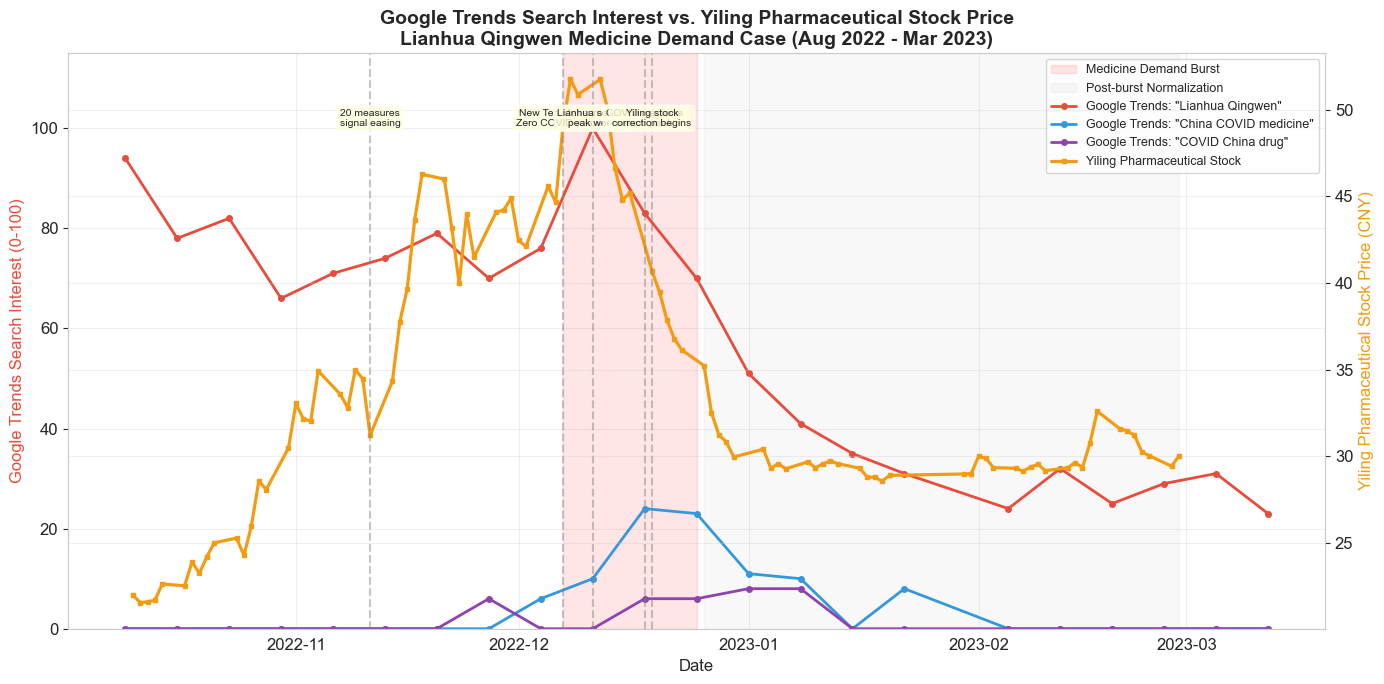

In [6]:
fig, ax1 = plt.subplots(figsize=(14, 7))
ax1.axvspan(*medicine_window, alpha=0.10, color='red', label='Medicine Demand Burst')
ax1.axvspan(post_window_start, pd.Timestamp('2023-02-28'), alpha=0.05, color='gray', label='Post-burst Normalization')

plot_cols = ['Lianhua Qingwen', 'China COVID medicine', 'COVID China drug']
colors_t = ['#E74C3C', '#3498DB', '#8E44AD']
for i, col in enumerate(plot_cols):
    ax1.plot(lianhua_merged_y['date'], lianhua_merged_y[col], '-o', color=colors_t[i],
             markersize=4, linewidth=2, label=f'Google Trends: "{col}"')
ax1.set_ylabel('Google Trends Search Interest (0-100)', fontsize=12, color='#E74C3C')
ax1.set_ylim(0, 115)

ax2 = ax1.twinx()
ax2.plot(yiling_stock['date'], yiling_stock['close'], '-s', color='#F39C12',
         markersize=3, linewidth=2.3, label='Yiling Pharmaceutical Stock')
ax2.set_ylabel('Yiling Pharmaceutical Stock Price (CNY)', fontsize=12, color='#F39C12')

peak_lianhua = lianhua_merged_y['Lianhua Qingwen'].max()
peak_week = lianhua_merged_y.loc[lianhua_merged_y['Lianhua Qingwen'].idxmax(), 'date'].date()
pre_dec7 = yiling_stock[yiling_stock['date'] < pd.Timestamp('2022-12-07')]
post_dec7 = yiling_stock[yiling_stock['date'] >= pd.Timestamp('2022-12-07')]
pre_ref = pre_dec7.iloc[-1]['close'] if len(pre_dec7) else yiling_stock.iloc[0]['close']
post_peak = post_dec7['close'].max()
ax1.annotate(
    f'KEY FINDING:\nLianhua Qingwen search peaked at {peak_lianhua} in week of {peak_week}.\n'
    f'Yiling stock rose from {pre_ref:.2f} to {post_peak:.2f} CNY around reopening\n'
    f'before correcting as the demand burst normalized.',
    xy=(pd.Timestamp('2022-09-05'), 36), fontsize=8.5,
    bbox=dict(boxstyle='round,pad=0.4', facecolor='lightyellow', alpha=0.9))

for ds, label in case4_events.items():
    dt = pd.Timestamp(ds)
    ax2.axvline(x=dt, color='gray', linestyle='--', alpha=0.45)
    ax2.annotate(label, xy=(dt, ax2.get_ylim()[1] * 0.94), fontsize=7.5,
                 ha='center', va='top',
                 bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow', alpha=0.8))

h1, l1 = ax1.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax1.legend(h1 + h2, l1 + l2, loc='upper right', fontsize=9)
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax1.xaxis.set_major_locator(mdates.MonthLocator())
ax1.set_xlabel('Date')
plt.title('Google Trends Search Interest vs. Yiling Pharmaceutical Stock Price\nLianhua Qingwen Medicine Demand Case (Aug 2022 - Mar 2023)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('figures/C4_Fig1_Lianhua_Trends_vs_Yiling.png', dpi=150, bbox_inches='tight')
plt.show()

### 5.2 Figure 2: Yiling Pharmaceutical Stock Price and Volume

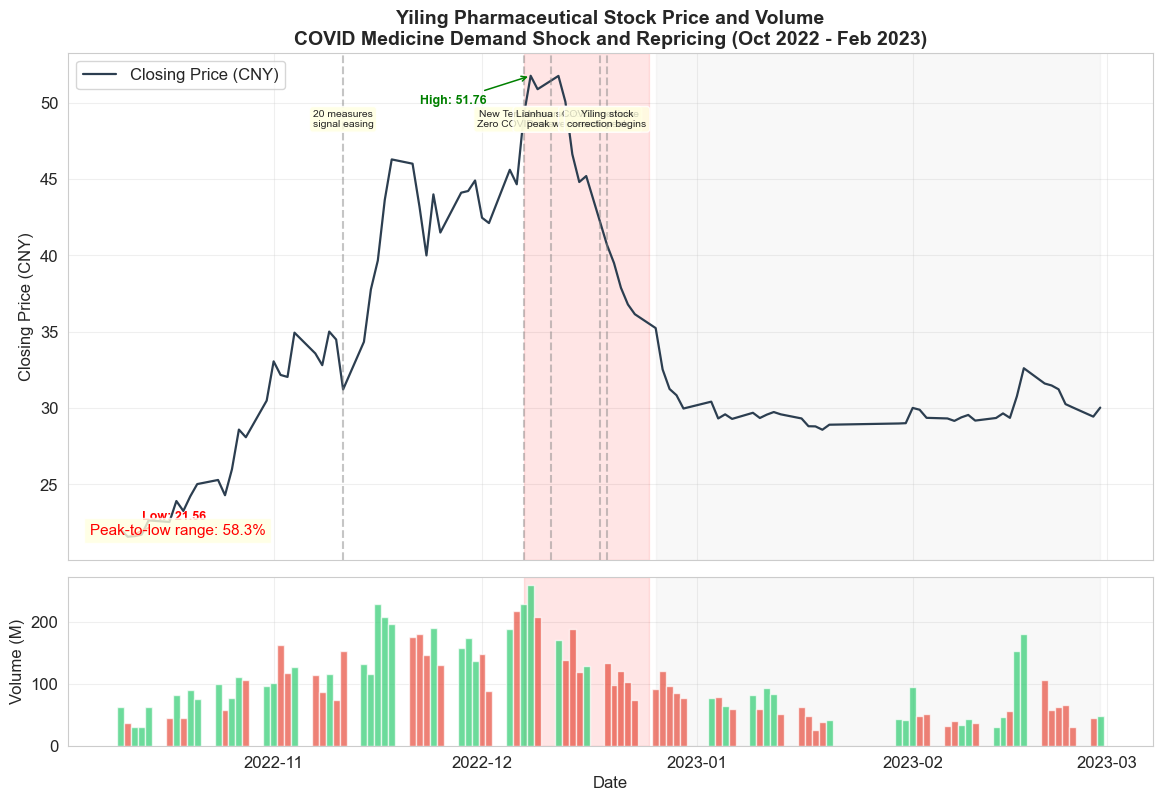

In [7]:
fig, (ax_p, ax_v) = plt.subplots(2, 1, figsize=(14, 9), height_ratios=[3, 1], sharex=True, gridspec_kw={'hspace': 0.05})
for ax in [ax_p, ax_v]:
    ax.axvspan(*medicine_window, alpha=0.10, color='red')
    ax.axvspan(post_window_start, pd.Timestamp('2023-02-28'), alpha=0.05, color='gray')

ax_p.plot(yiling_stock['date'], yiling_stock['close'], color='#2C3E50', linewidth=1.6, label='Closing Price (CNY)')
mi, mx = yiling_stock['close'].idxmin(), yiling_stock['close'].idxmax()
ax_p.annotate(f"Low: {yiling_stock.loc[mi, 'close']:.2f}", xy=(yiling_stock.loc[mi, 'date'], yiling_stock.loc[mi, 'close']),
              xytext=(10, 12), textcoords='offset points', fontsize=9, color='red', fontweight='bold',
              arrowprops=dict(arrowstyle='->', color='red', lw=1.1))
ax_p.annotate(f"High: {yiling_stock.loc[mx, 'close']:.2f}", xy=(yiling_stock.loc[mx, 'date'], yiling_stock.loc[mx, 'close']),
              xytext=(-80, -20), textcoords='offset points', fontsize=9, color='green', fontweight='bold',
              arrowprops=dict(arrowstyle='->', color='green', lw=1.1))

correction = (yiling_stock.loc[mx, 'close'] - yiling_stock['close'].min()) / yiling_stock.loc[mx, 'close'] * 100
ax_p.text(0.02, 0.05, f'Peak-to-low range: {correction:.1f}%', transform=ax_p.transAxes,
          fontsize=11, color='red', bbox=dict(facecolor='lightyellow', alpha=0.8))

for ds, label in case4_events.items():
    dt = pd.Timestamp(ds)
    ax_p.axvline(x=dt, color='gray', linestyle='--', alpha=0.45)
    ax_p.annotate(label, xy=(dt, ax_p.get_ylim()[1] * 0.93), fontsize=7.5,
                  ha='center', va='top',
                  bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow', alpha=0.8))

ax_p.set_ylabel('Closing Price (CNY)')
ax_p.legend(loc='upper left')

colors_v = ['#E74C3C' if r < 0 else '#2ECC71' for r in yiling_stock['daily_return'].fillna(0)]
ax_v.bar(yiling_stock['date'], yiling_stock['volume'] / 1e6, width=1, color=colors_v, alpha=0.7)
ax_v.set_ylabel('Volume (M)')
ax_v.set_xlabel('Date')
ax_p.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax_p.xaxis.set_major_locator(mdates.MonthLocator())
ax_p.set_title('Yiling Pharmaceutical Stock Price and Volume\nCOVID Medicine Demand Shock and Repricing (Oct 2022 - Feb 2023)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('figures/C4_Fig2_Yiling_Price_Volume.png', dpi=150, bbox_inches='tight')
plt.show()

### 5.3 Figure 3: Yiling vs. Tongrentang Comparison

Tongrentang is included as a broader traditional-medicine/pharmaceutical comparator. This helps separate a product-specific Lianhua Qingwen signal from a general medicine-sector reopening signal.

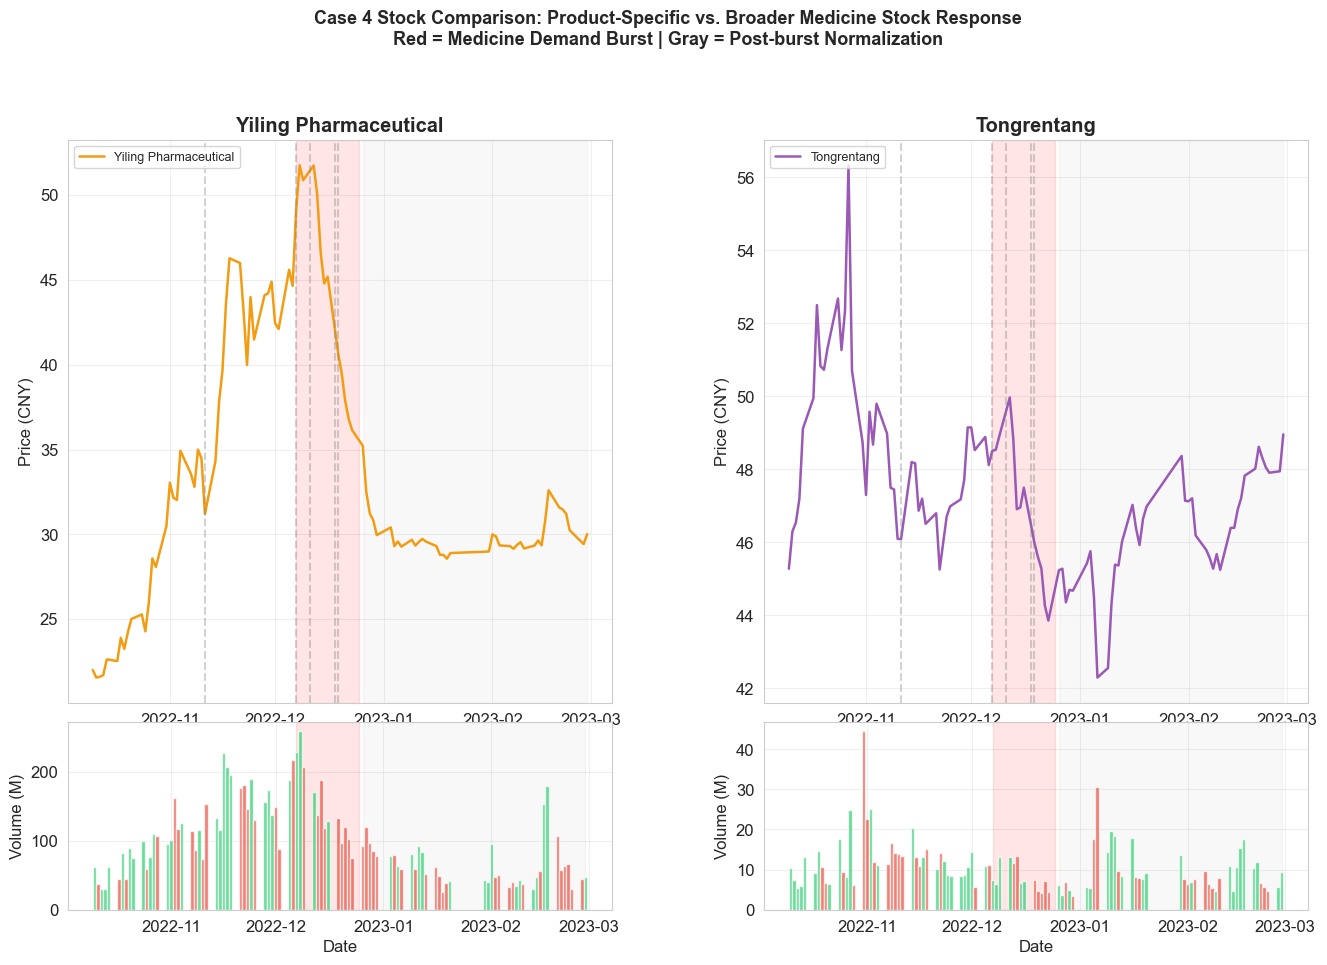

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10), gridspec_kw={'height_ratios': [3, 1], 'hspace': 0.05, 'wspace': 0.28})
(ax_yp, ax_yv), (ax_tp, ax_tv) = axes[:, 0], axes[:, 1]

for ax in [ax_yp, ax_yv, ax_tp, ax_tv]:
    ax.axvspan(*medicine_window, alpha=0.10, color='red')
    ax.axvspan(post_window_start, pd.Timestamp('2023-02-28'), alpha=0.05, color='gray')

ax_yp.plot(yiling_stock['date'], yiling_stock['close'], color='#F39C12', linewidth=1.8, label='Yiling Pharmaceutical')
ax_yp.set_ylabel('Price (CNY)')
ax_yp.set_title('Yiling Pharmaceutical', fontweight='bold')
ax_yp.legend(loc='upper left', fontsize=9)

ax_tp.plot(tongrentang_stock['date'], tongrentang_stock['close'], color='#9B59B6', linewidth=1.8, label='Tongrentang')
ax_tp.set_ylabel('Price (CNY)')
ax_tp.set_title('Tongrentang', fontweight='bold')
ax_tp.legend(loc='upper left', fontsize=9)

for ds in case4_events.keys():
    ax_yp.axvline(x=pd.Timestamp(ds), color='gray', linestyle='--', alpha=0.35)
    ax_tp.axvline(x=pd.Timestamp(ds), color='gray', linestyle='--', alpha=0.35)

colors_y = ['#E74C3C' if r < 0 else '#2ECC71' for r in yiling_stock['daily_return'].fillna(0)]
colors_t = ['#E74C3C' if r < 0 else '#2ECC71' for r in tongrentang_stock['daily_return'].fillna(0)]
ax_yv.bar(yiling_stock['date'], yiling_stock['volume'] / 1e6, width=1, color=colors_y, alpha=0.7)
ax_tv.bar(tongrentang_stock['date'], tongrentang_stock['volume'] / 1e6, width=1, color=colors_t, alpha=0.7)
ax_yv.set_ylabel('Volume (M)')
ax_tv.set_ylabel('Volume (M)')
ax_yv.set_xlabel('Date')
ax_tv.set_xlabel('Date')

for ax in [ax_yp, ax_yv, ax_tp, ax_tv]:
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

plt.suptitle('Case 4 Stock Comparison: Product-Specific vs. Broader Medicine Stock Response\nRed = Medicine Demand Burst | Gray = Post-burst Normalization', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('figures/C4_Fig3_Yiling_Tongrentang_Price_Volume.png', dpi=150, bbox_inches='tight')
plt.show()

### 5.4 Figure 4: Product and Company Related Queries

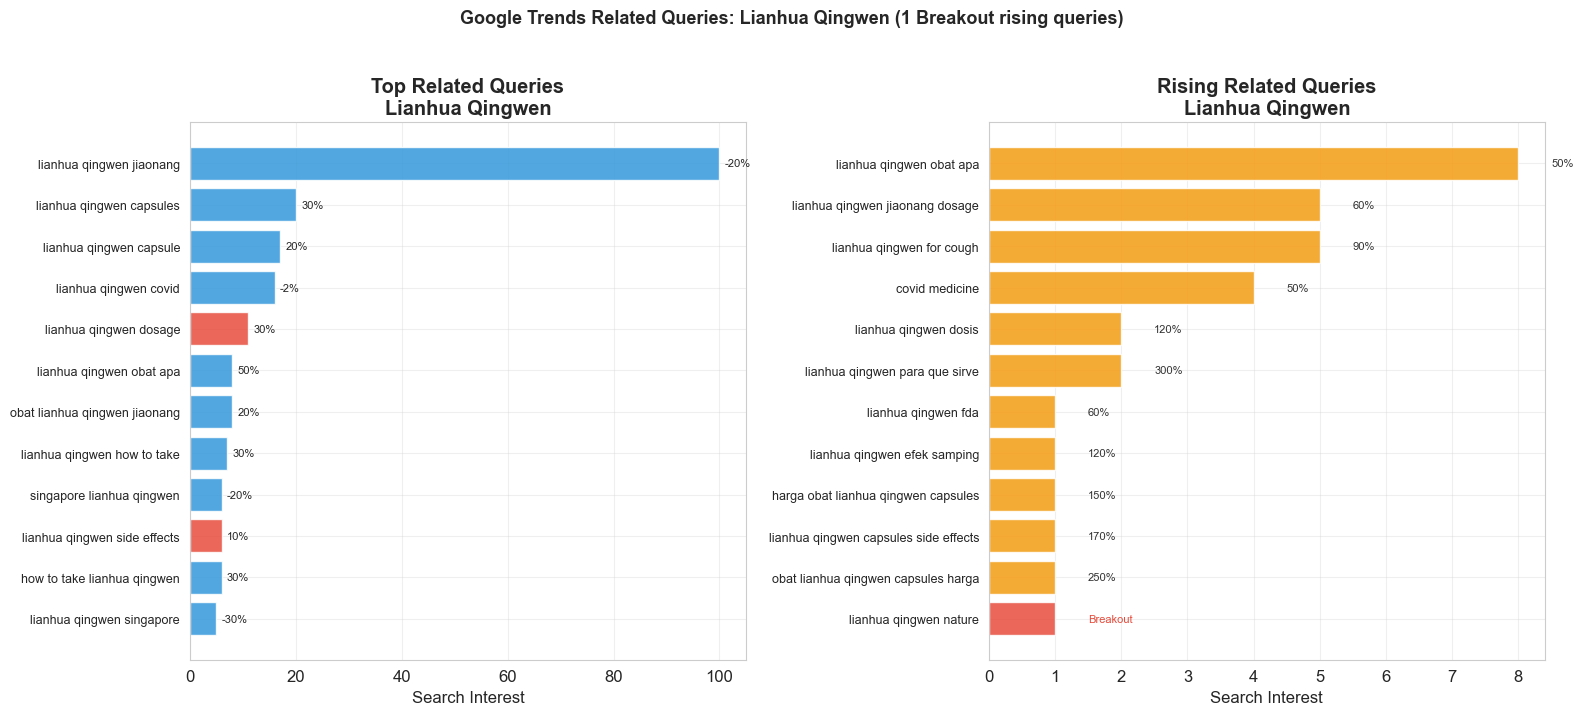

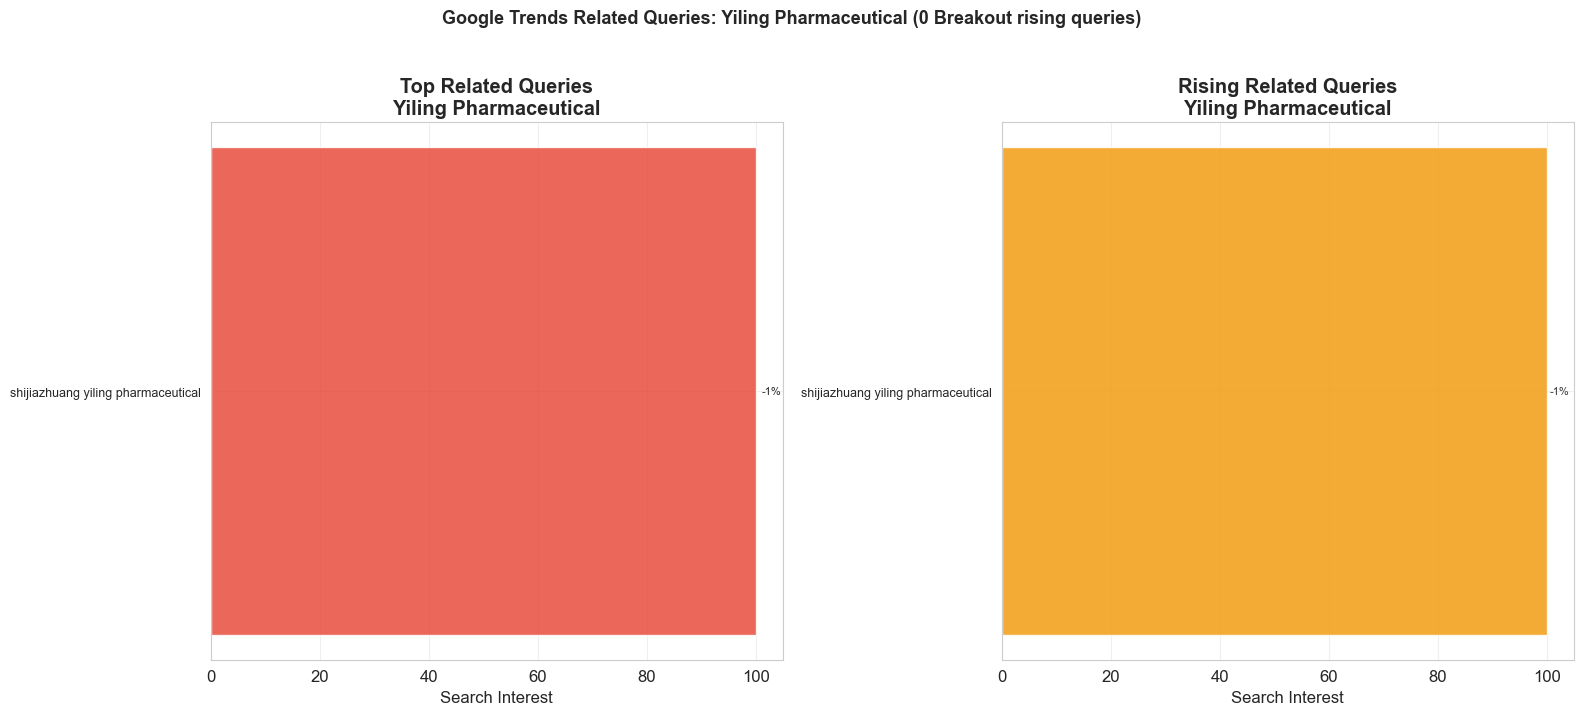

In [9]:
def plot_query_pair(top_df, rise_df, title, filename, n=12):
    fig, (a1, a2) = plt.subplots(1, 2, figsize=(16, 7))
    td = top_df.head(n).sort_values('search_interest')
    rd = rise_df.head(n).sort_values('search_interest')

    top_colors = ['#E74C3C' if any(k in str(q).lower() for k in ['stock', 'price', 'pharmaceutical', 'dose', 'dosage', 'side effect']) else '#3498DB' for q in td['query']]
    a1.barh(range(len(td)), td['search_interest'], color=top_colors, alpha=0.85)
    a1.set_yticks(range(len(td)))
    a1.set_yticklabels(td['query'], fontsize=9)
    a1.set_xlabel('Search Interest')
    a1.set_title(f'Top Related Queries\n{title}', fontweight='bold')
    for i, (_, r) in enumerate(td.iterrows()):
        a1.text(r['search_interest'] + 1, i, str(r['change_pct']), fontsize=8, va='center')

    rise_colors = ['#E74C3C' if str(c) == 'Breakout' else '#F39C12' for c in rd['change_pct']]
    a2.barh(range(len(rd)), rd['search_interest'], color=rise_colors, alpha=0.85)
    a2.set_yticks(range(len(rd)))
    a2.set_yticklabels(rd['query'], fontsize=9)
    a2.set_xlabel('Search Interest')
    a2.set_title(f'Rising Related Queries\n{title}', fontweight='bold')
    for i, (_, r) in enumerate(rd.iterrows()):
        a2.text(r['search_interest'] + 0.5, i, str(r['change_pct']), fontsize=8, va='center',
                color='#E74C3C' if str(r['change_pct']) == 'Breakout' else '#333')

    n_breakout = (rise_df['change_pct'] == 'Breakout').sum()
    plt.suptitle(f'Google Trends Related Queries: {title} ({n_breakout} Breakout rising queries)', fontsize=13, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig(filename, dpi=150, bbox_inches='tight')
    plt.show()

plot_query_pair(lianhua_top, lianhua_rise, 'Lianhua Qingwen', 'figures/C4_Fig4_Lianhua_Queries.png')
plot_query_pair(yiling_top, yiling_rise, 'Yiling Pharmaceutical', 'figures/C4_Fig5_Yiling_Queries.png', n=8)

### 5.5 Figure 5: Broader COVID and COVID Drug Query Evidence

These files are sparse, but they are useful for showing that Case 4 is embedded in a broader COVID medicine information environment rather than only a product-name search.

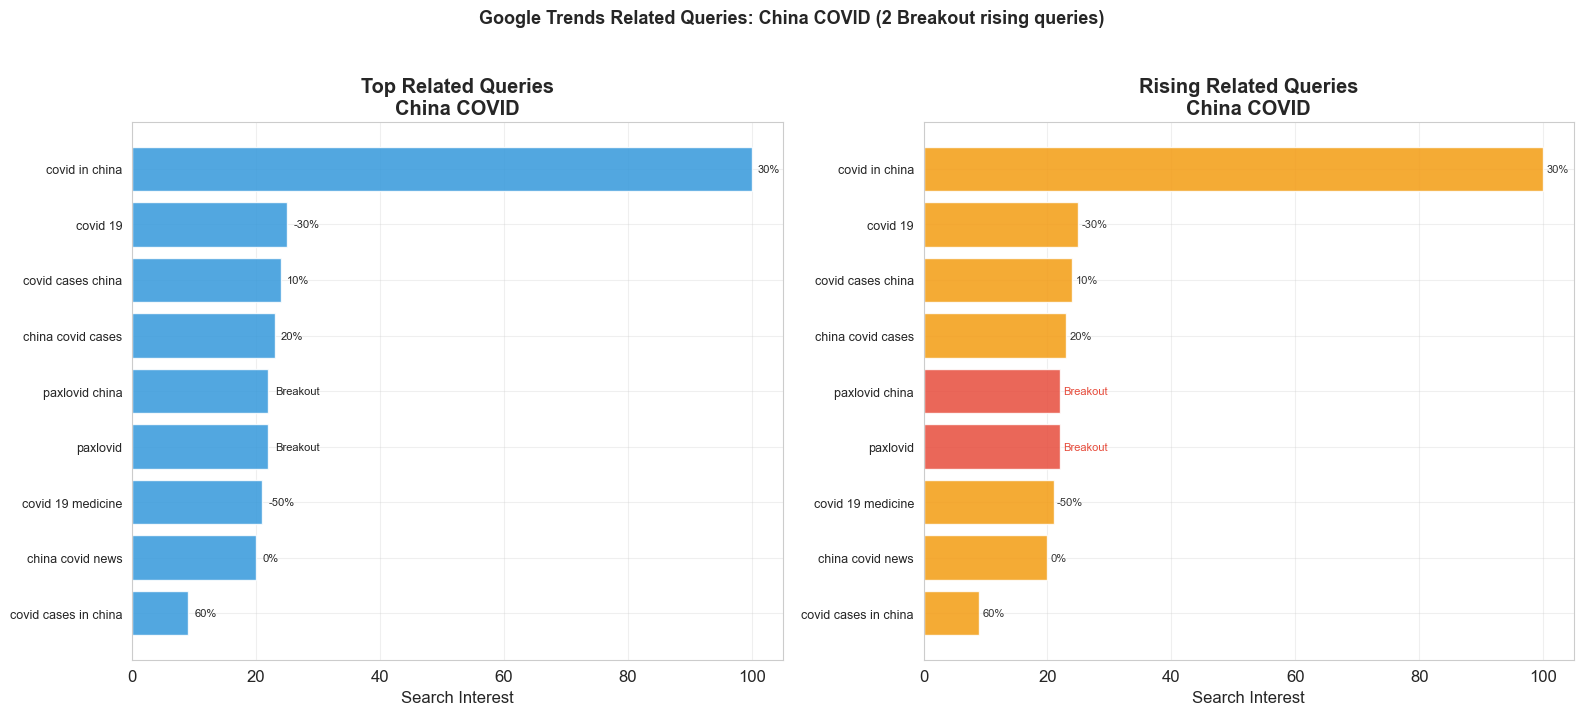

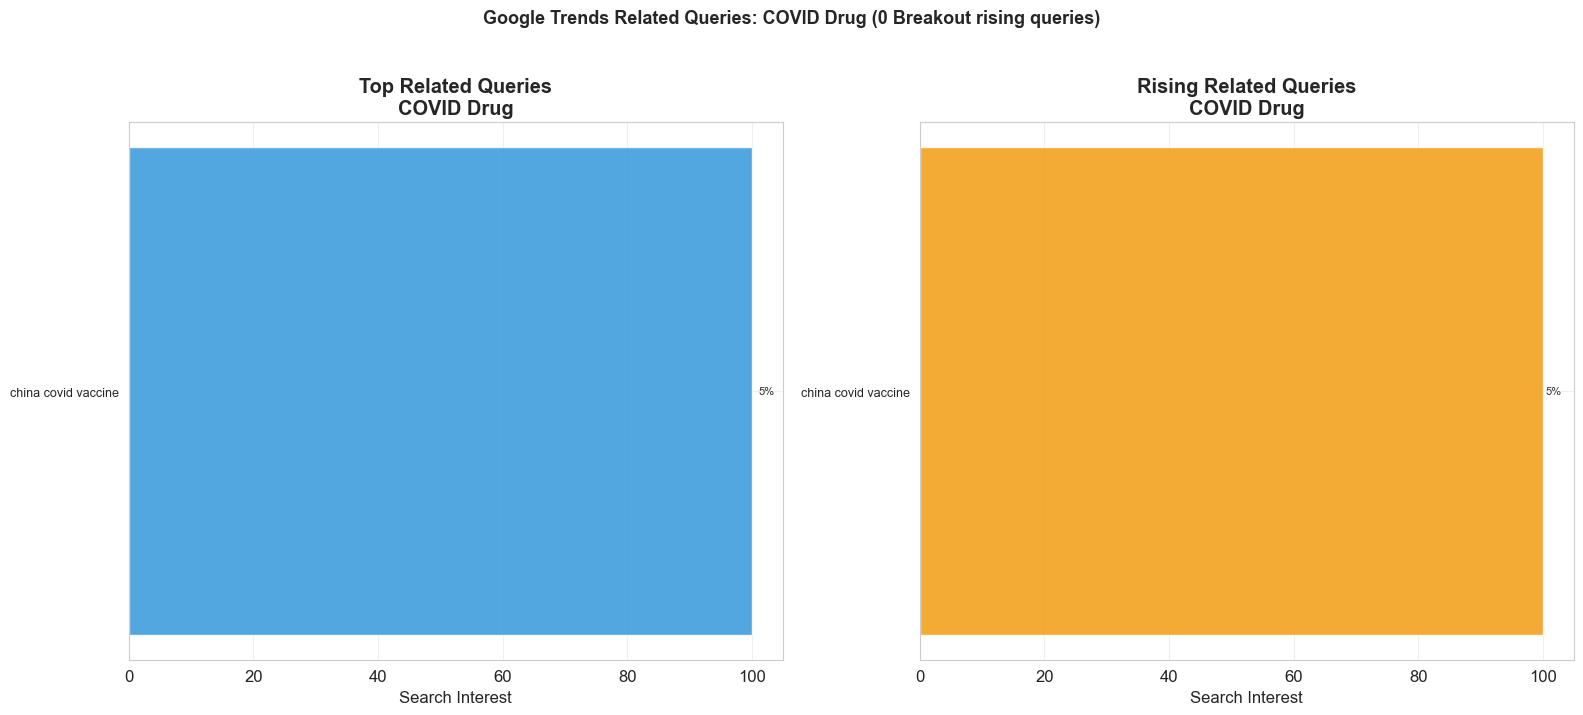

In [10]:
plot_query_pair(china_covid_top, china_covid_rise, 'China COVID', 'figures/C4_Fig6_China_COVID_Queries.png')
plot_query_pair(covid_drug_top, covid_drug_rise, 'COVID Drug', 'figures/C4_Fig7_COVID_Drug_Queries.png', n=8)

## 6. Statistical Analysis

### 6.1 Descriptive Statistics

Three periods are used:
- **Pre-reopening**: before Dec 7, 2022
- **Medicine demand burst**: Dec 7 - Dec 25, 2022
- **Post-burst normalization**: after Dec 25, 2022

In [11]:
def period_summary(stock_df, name, cs, ce):
    pre = stock_df[stock_df['date'] < cs]
    dur = stock_df[(stock_df['date'] >= cs) & (stock_df['date'] <= ce)]
    post = stock_df[stock_df['date'] > ce]
    pk, tr = stock_df['close'].max(), stock_df['close'].min()
    print(f"\n{'='*65}")
    print(name)
    print(f"{'='*65}")
    print(f"Pre avg:   {pre['close'].mean():.2f}  |  Burst avg: {dur['close'].mean():.2f}  |  Post avg: {post['close'].mean():.2f}")
    print(f"Peak: {pk:.2f}  |  Trough: {tr:.2f}  |  Peak-to-trough range: {((tr-pk)/pk*100):.1f}%")
    if len(pre) > 0 and pre['volume'].mean() > 0:
        vol_change = (dur['volume'].mean() / pre['volume'].mean() - 1) * 100
        print(f"Volume: pre {pre['volume'].mean()/1e6:.1f}M -> burst {dur['volume'].mean()/1e6:.1f}M ({vol_change:.0f}% change)")

period_summary(yiling_stock, 'Yiling Pharmaceutical', *medicine_window)
period_summary(tongrentang_stock, 'Tongrentang', *medicine_window)

print('\nTrend peaks:')
for col in trend_cols:
    peak_idx = lianhua_trends[col].idxmax()
    print(f"  {col}: peak {lianhua_trends.loc[peak_idx, col]} in week of {lianhua_trends.loc[peak_idx, 'date'].date()}")


Yiling Pharmaceutical
Pre avg:   33.68  |  Burst avg: 44.70  |  Post avg: 30.00
Peak: 51.76  |  Trough: 21.56  |  Peak-to-trough range: -58.3%
Volume: pre 118.5M -> burst 151.4M (28% change)

Tongrentang
Pre avg:   48.59  |  Burst avg: 47.01  |  Post avg: 46.22
Peak: 56.33  |  Trough: 42.30  |  Peak-to-trough range: -24.9%
Volume: pre 12.8M -> burst 8.2M (-36% change)

Trend peaks:
  Lianhua Qingwen: peak 100 in week of 2022-12-11
  Yiling Pharmaceutical: peak 0 in week of 2022-08-28
  China COVID medicine: peak 24 in week of 2022-12-18
  COVID China drug: peak 8 in week of 2023-01-01


### 6.2 Correlation Analysis

**Hypothesis:** Product and COVID medicine search interest should be positively associated with related pharmaceutical stock prices during the demand burst, but the relationship may reverse or weaken after the speculative phase corrects.


Correlation: Lianhua - Yiling
Pearson r=0.3611 (p=0.0987)  |  Spearman rho=0.2501 (p=0.2615)
Best lag: 1 weeks, r=0.3923 (p=0.0786)


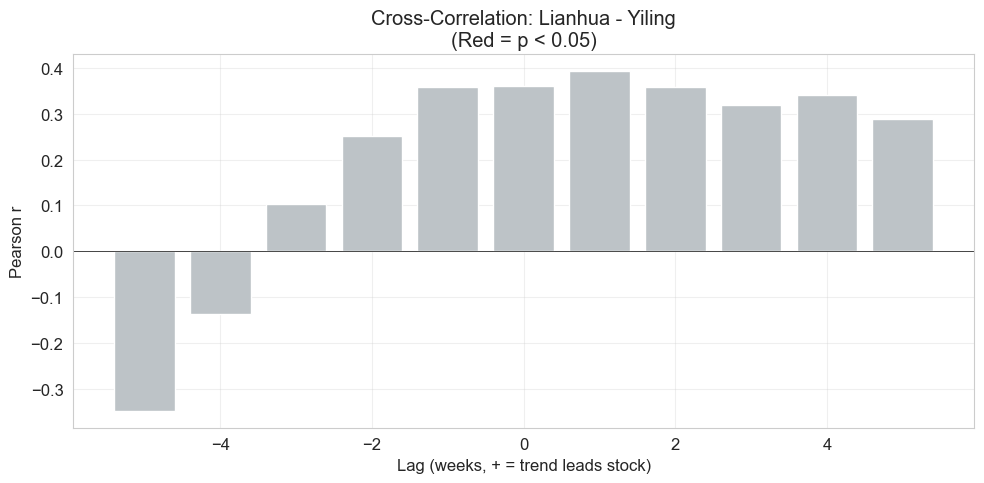


Correlation: Lianhua - Tongrentang
Pearson r=0.2754 (p=0.2147)  |  Spearman rho=0.2055 (p=0.3589)
Best lag: -3 weeks, r=0.5556 (p=0.0135)


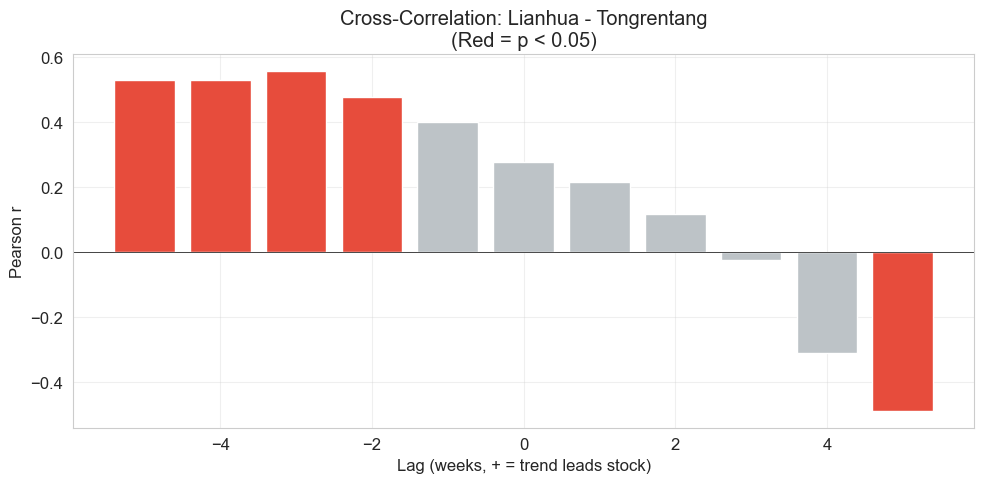


Correlation: COVID Medicine - Yiling
Pearson r=0.5377 (p=0.0098)*  |  Spearman rho=0.4484 (p=0.0364)*
Best lag: -2 weeks, r=0.8114 (p=0.0000)


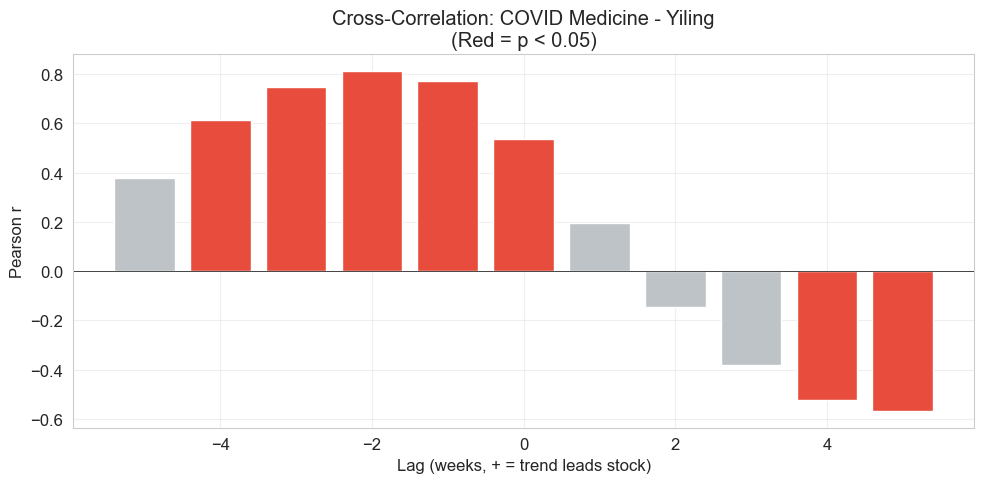

In [12]:
def correlation_analysis(mdf, tcol, scol='avg_close', name='Case', prefix='C4'):
    v = mdf[[tcol, scol]].dropna()
    pr, pp = stats.pearsonr(v[tcol], v[scol])
    sr, sp = stats.spearmanr(v[tcol], v[scol])
    print(f"\n{'='*55}")
    print(f'Correlation: {name}')
    print(f"Pearson r={pr:.4f} (p={pp:.4f}){'*' if pp < 0.05 else ''}  |  Spearman rho={sr:.4f} (p={sp:.4f}){'*' if sp < 0.05 else ''}")

    ml = min(5, len(v) // 3)
    lags = []
    for lag in range(-ml, ml + 1):
        x = v[tcol].iloc[max(0, -lag):len(v) - max(0, lag)].values
        y = v[scol].iloc[max(0, lag):len(v) - max(0, -lag)].values
        if len(x) > 3 and np.std(x) > 0 and np.std(y) > 0:
            r, p = stats.pearsonr(x, y)
            lags.append({'lag': lag, 'r': r, 'p': p})
    ldf = pd.DataFrame(lags)
    if len(ldf) == 0:
        print('No valid lag correlations.')
        return ldf
    best = ldf.loc[ldf['r'].abs().idxmax()]
    print(f"Best lag: {int(best['lag'])} weeks, r={best['r']:.4f} (p={best['p']:.4f})")

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.bar(ldf['lag'], ldf['r'], color=['#E74C3C' if p < 0.05 else '#BDC3C7' for p in ldf['p']])
    ax.axhline(y=0, color='black', linewidth=0.5)
    ax.set_xlabel('Lag (weeks, + = trend leads stock)')
    ax.set_ylabel('Pearson r')
    ax.set_title(f'Cross-Correlation: {name}\n(Red = p < 0.05)')
    plt.tight_layout()
    safe = name.replace(' ', '_').replace('/', '-')
    plt.savefig(f'figures/{prefix}_XCorr_{safe}.png', dpi=150)
    plt.show()
    return ldf

lag_y_lh = correlation_analysis(lianhua_merged_y, 'Lianhua Qingwen', name='Lianhua - Yiling')
lag_t_lh = correlation_analysis(lianhua_merged_t, 'Lianhua Qingwen', name='Lianhua - Tongrentang')
lag_y_med = correlation_analysis(lianhua_merged_y, 'China COVID medicine', name='COVID Medicine - Yiling')

### 6.3 Granger Causality Test

- **H0**: search interest does NOT Granger-cause stock price
- **H1**: search interest DOES Granger-cause stock price
- Reject H0 if p < 0.05

Because the sample is small and the shock is event-driven, Granger results are treated as timing evidence rather than proof of true causation.

In [13]:
def check_stat(s, name):
    s = s.dropna()
    if len(s) < 8 or s.nunique() <= 1:
        print(f'  ADF {name}: skipped; too few observations or constant series')
        return True
    r = adfuller(s, autolag='AIC')
    ok = r[1] < 0.05
    print(f"  ADF {name}: stat={r[0]:.3f}, p={r[1]:.4f} -> {'Stationary' if ok else 'Non-stationary (diff)'}")
    return ok

def granger_test(mdf, tcol, scol='avg_close', ml=3, name='Case'):
    print(f"\n{'='*65}")
    print(f"Granger Causality: {name} (n={len(mdf.dropna(subset=[tcol, scol]))})")
    print(f"{'='*65}")
    df = mdf[[tcol, scol]].dropna().copy()
    tu, su = tcol, scol
    if not check_stat(df[tcol], tcol):
        df[tcol + '_d'] = df[tcol].diff()
        tu = tcol + '_d'
    if not check_stat(df[scol], scol):
        df[scol + '_d'] = df[scol].diff()
        su = scol + '_d'
    df = df.dropna()
    if len(df) < ml + 5:
        ml = max(1, len(df) // 4)
        print(f'  Reduced max_lag to {ml}')

    print(f'\nForward: {tcol} -> {scol}')
    try:
        rf = grangercausalitytests(df[[su, tu]].values, maxlag=ml, verbose=False)
        for lag in range(1, ml + 1):
            f, p = rf[lag][0]['ssr_ftest'][:2]
            print(f"  Lag {lag}: F={f:.3f}, p={p:.4f} {'YES *' if p < 0.05 else 'no'}")
    except Exception as e:
        print(f'  Error: {e}')

    print(f'\nReverse: {scol} -> {tcol}')
    try:
        rr = grangercausalitytests(df[[tu, su]].values, maxlag=ml, verbose=False)
        for lag in range(1, ml + 1):
            f, p = rr[lag][0]['ssr_ftest'][:2]
            print(f"  Lag {lag}: F={f:.3f}, p={p:.4f} {'YES *' if p < 0.05 else 'no'}")
    except Exception as e:
        print(f'  Error: {e}')

granger_test(lianhua_merged_y, 'Lianhua Qingwen', ml=3, name='Lianhua -> Yiling')
granger_test(lianhua_merged_t, 'Lianhua Qingwen', ml=3, name='Lianhua -> Tongrentang')
granger_test(lianhua_merged_y, 'China COVID medicine', ml=3, name='COVID Medicine -> Yiling')


Granger Causality: Lianhua -> Yiling (n=22)
  ADF Lianhua Qingwen: stat=-1.024, p=0.7445 -> Non-stationary (diff)
  ADF avg_close: stat=-1.187, p=0.6792 -> Non-stationary (diff)

Forward: Lianhua Qingwen -> avg_close
  Lag 1: F=0.065, p=0.8012 no
  Lag 2: F=1.116, p=0.3551 no
  Lag 3: F=9.232, p=0.0024 YES *

Reverse: avg_close -> Lianhua Qingwen
  Lag 1: F=2.530, p=0.1301 no
  Lag 2: F=2.153, p=0.1530 no
  Lag 3: F=3.019, p=0.0758 no

Granger Causality: Lianhua -> Tongrentang (n=22)
  ADF Lianhua Qingwen: stat=-1.024, p=0.7445 -> Non-stationary (diff)
  ADF avg_close: stat=-2.877, p=0.0480 -> Stationary

Forward: Lianhua Qingwen -> avg_close
  Lag 1: F=0.606, p=0.4470 no
  Lag 2: F=2.865, p=0.0906 no
  Lag 3: F=1.414, p=0.2910 no

Reverse: avg_close -> Lianhua Qingwen
  Lag 1: F=0.489, p=0.4937 no
  Lag 2: F=0.206, p=0.8160 no
  Lag 3: F=1.780, p=0.2090 no

Granger Causality: COVID Medicine -> Yiling (n=22)
  ADF China COVID medicine: stat=-3.685, p=0.0043 -> Stationary
  ADF avg_clo

### 6.4 Event Study: Cumulative Returns

The primary event date is Dec 7, 2022, when reopening accelerated. A secondary event date is Dec 11, the week of the Lianhua Qingwen search peak. Because Yiling had a strong pre-event run-up, this section uses raw cumulative return as the main event-window measure and prints the pre-event median daily return for context.

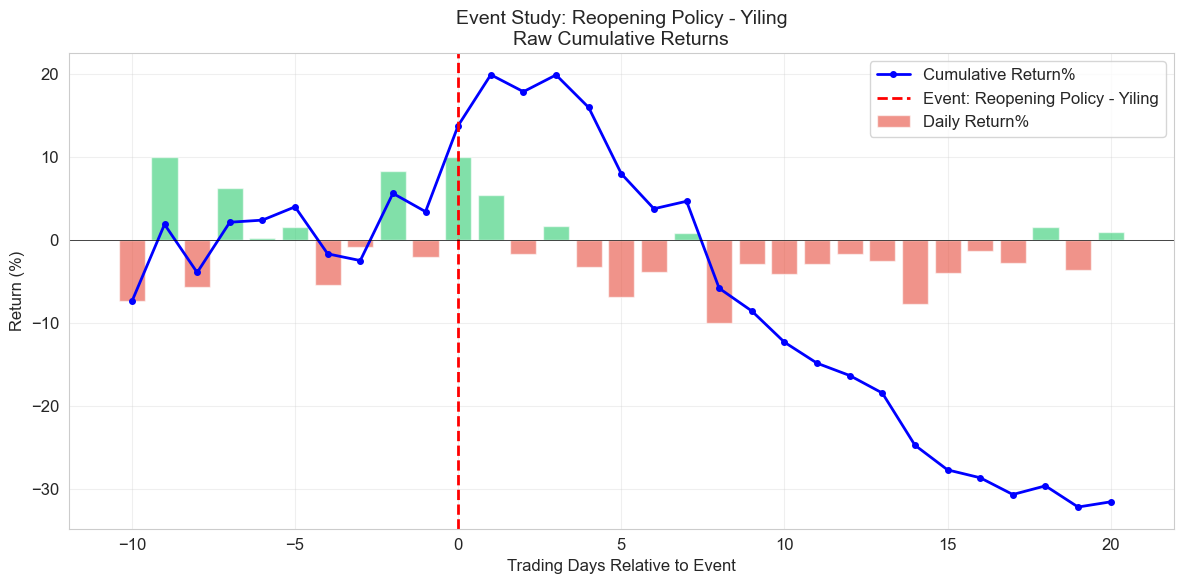

Raw cumulative return at day +20: -31.50%
Pre-event median daily return: 1.08%


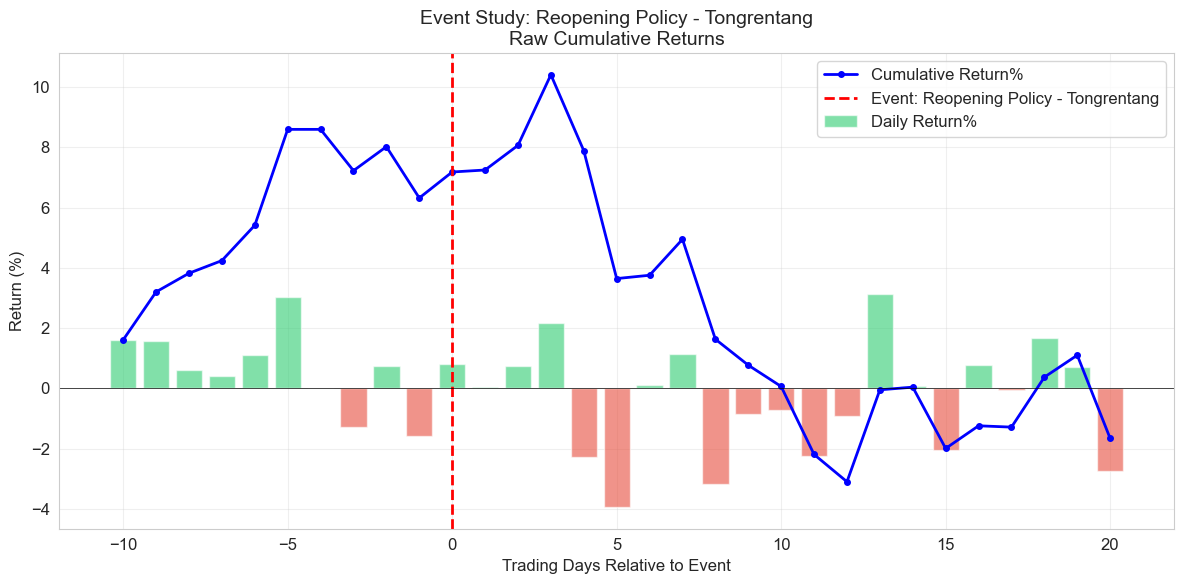

Raw cumulative return at day +20: -1.66%
Pre-event median daily return: -0.02%


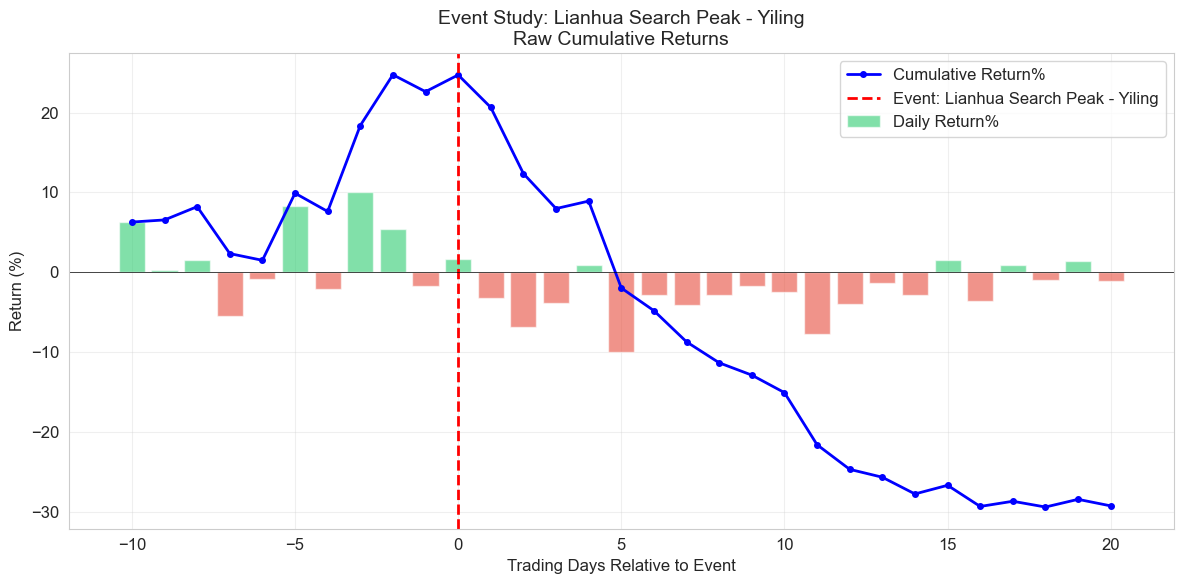

Raw cumulative return at day +20: -29.28%
Pre-event median daily return: 3.30%


In [14]:
def event_study(sdf, edate, ename, wb=10, wa=20, prefix='C4'):
    edt = pd.Timestamp(edate)
    df = sdf.copy()
    candidates = df[df['date'] >= edt].index
    if len(candidates) == 0:
        print(f'No data from {edate} onwards for {ename}')
        return None
    ei = candidates[0]
    pre_returns = df.loc[max(0, ei - wb - 30):ei - wb, 'daily_return'].dropna()
    baseline_return = pre_returns.median() if len(pre_returns) else 0
    w = df.loc[max(0, ei - wb):min(len(df) - 1, ei + wa)].copy()
    w['event_return'] = w['daily_return'].fillna(0)
    w['cr'] = (1 + w['event_return']).cumprod() - 1
    w['day'] = range(-min(wb, ei - w.index[0]), len(w) - min(wb, ei - w.index[0]))

    fig, ax = plt.subplots(figsize=(12, 6))
    ax.bar(w['day'], w['event_return'] * 100, color=['#E74C3C' if x < 0 else '#2ECC71' for x in w['event_return']], alpha=0.6, label='Daily Return%')
    ax.plot(w['day'], w['cr'] * 100, 'b-o', linewidth=2, markersize=4, label='Cumulative Return%')
    ax.axvline(x=0, color='red', linestyle='--', linewidth=2, label=f'Event: {ename}')
    ax.axhline(y=0, color='black', linewidth=0.5)
    ax.set_xlabel('Trading Days Relative to Event')
    ax.set_ylabel('Return (%)')
    ax.set_title(f'Event Study: {ename}\nRaw Cumulative Returns', fontsize=14)
    ax.legend()
    plt.tight_layout()
    safe = ename.replace(' ', '_').replace('/', '-')
    plt.savefig(f'figures/{prefix}_ES_{safe}.png', dpi=150)
    plt.show()
    print(f"Raw cumulative return at day +{wa}: {w['cr'].iloc[-1]*100:.2f}%")
    print(f"Pre-event median daily return: {baseline_return*100:.2f}%")
    return w

es_y_reopen = event_study(yiling_stock, '2022-12-07', 'Reopening Policy - Yiling', wb=10, wa=20)
es_t_reopen = event_study(tongrentang_stock, '2022-12-07', 'Reopening Policy - Tongrentang', wb=10, wa=20)
es_y_peak = event_study(yiling_stock, '2022-12-11', 'Lianhua Search Peak - Yiling', wb=10, wa=20)

## 7. Cross-Stock Normalized Comparison

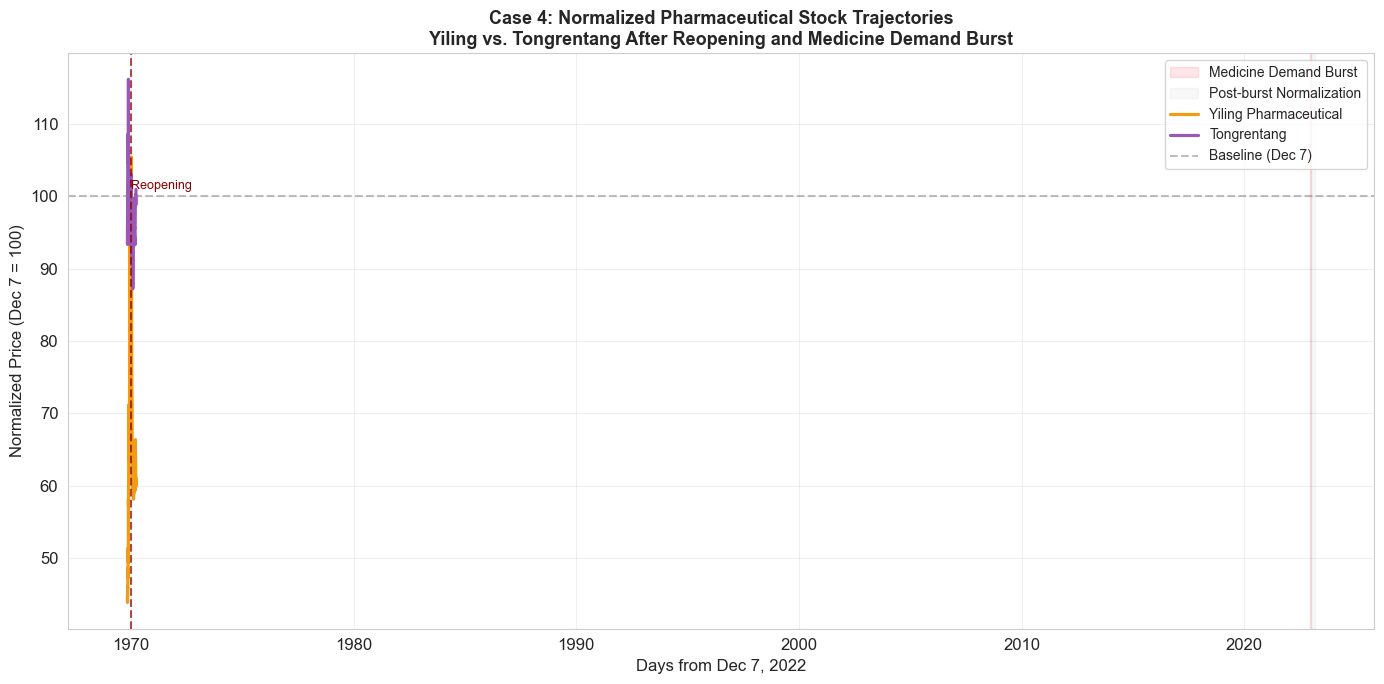

In [15]:
fig, ax = plt.subplots(figsize=(14, 7))
baseline = pd.Timestamp('2022-12-07')
ax.axvspan(*medicine_window, alpha=0.10, color='red', label='Medicine Demand Burst')
ax.axvspan(post_window_start, pd.Timestamp('2023-02-28'), alpha=0.05, color='gray', label='Post-burst Normalization')

stock_configs = [
    (yiling_stock, 'Yiling Pharmaceutical', '#F39C12'),
    (tongrentang_stock, 'Tongrentang', '#9B59B6'),
]

for sdf, nm, c in stock_configs:
    s = sdf.copy()
    p0_row = s[s['date'] >= baseline]
    if len(p0_row) == 0:
        continue
    p0 = p0_row.iloc[0]['close']
    s['norm'] = s['close'] / p0 * 100
    s['d'] = (s['date'] - baseline).dt.days
    ax.plot(s['d'], s['norm'], linewidth=2.3, label=nm, color=c)

ax.axhline(y=100, color='gray', linestyle='--', alpha=0.5, label='Baseline (Dec 7)')
ax.axvline(x=0, color='darkred', linestyle='--', alpha=0.7)
ax.text(0.5, 101, 'Reopening', fontsize=9, color='darkred')
ax.set_xlabel('Days from Dec 7, 2022')
ax.set_ylabel('Normalized Price (Dec 7 = 100)')
ax.legend(loc='upper right', fontsize=10)
plt.title('Case 4: Normalized Pharmaceutical Stock Trajectories\nYiling vs. Tongrentang After Reopening and Medicine Demand Burst', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('figures/C4_Fig8_CrossStock_Normalized.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Data Coverage Appendix

This cell documents that every Case 4 related dataset in the repository is loaded into the notebook.

In [16]:
coverage = pd.DataFrame([
    {'file': 'lianhua_trends.csv', 'rows': len(lianhua_trends), 'role': 'weekly Google Trends time series'},
    {'file': 'yiling_pharma_stock.csv', 'rows': len(yiling_stock), 'role': 'main related stock'},
    {'file': 'tongrentang_stock.csv', 'rows': len(tongrentang_stock), 'role': 'comparison pharmaceutical stock'},
    {'file': 'lianhua_top_queries.csv', 'rows': len(lianhua_top), 'role': 'product top related queries'},
    {'file': 'lianhua_rising_queries.csv', 'rows': len(lianhua_rise), 'role': 'product rising related queries'},
    {'file': 'yiling_top_queries.csv', 'rows': len(yiling_top), 'role': 'company top related queries'},
    {'file': 'yiling_rising_queries.csv', 'rows': len(yiling_rise), 'role': 'company rising related queries'},
    {'file': 'china_covid_top_queries.csv', 'rows': len(china_covid_top), 'role': 'broader COVID top related queries'},
    {'file': 'china_covid_rising_queries.csv', 'rows': len(china_covid_rise), 'role': 'broader COVID rising related queries'},
    {'file': 'covid_drug_top_queries.csv', 'rows': len(covid_drug_top), 'role': 'drug-related top queries'},
    {'file': 'covid_drug_rising_queries.csv', 'rows': len(covid_drug_rise), 'role': 'drug-related rising queries'},
])
print(coverage.to_string(index=False))

                          file  rows                                 role
            lianhua_trends.csv    31     weekly Google Trends time series
       yiling_pharma_stock.csv    96                   main related stock
         tongrentang_stock.csv    96      comparison pharmaceutical stock
       lianhua_top_queries.csv    20          product top related queries
    lianhua_rising_queries.csv    20       product rising related queries
        yiling_top_queries.csv     1          company top related queries
     yiling_rising_queries.csv     1       company rising related queries
   china_covid_top_queries.csv     9    broader COVID top related queries
china_covid_rising_queries.csv     9 broader COVID rising related queries
    covid_drug_top_queries.csv     1             drug-related top queries
 covid_drug_rising_queries.csv     1          drug-related rising queries


## 9. Key Findings

**1. Case 4 is a medicine-demand pathway.** The sequence is not a boycott, panic-buying commodity shock, or policy-forcing protest. It is a reopening-driven health-information and medicine-demand shock centered on Lianhua Qingwen and related pharmaceutical firms.

**2. Search attention is product-specific but embedded in a broader COVID context.** The `Lianhua Qingwen` search series peaks at 100 in the week of Dec 11, while `China COVID medicine` peaks in the following week. The related-query files show both product/dosage interest and broader COVID-treatment attention such as Paxlovid.

**3. Yiling shows stronger direct exposure than Tongrentang.** Yiling is the product-linked stock, while Tongrentang is a useful comparator for broader traditional-medicine/pharmaceutical sentiment.

**4. The market response includes both rally and correction.** Yiling had already risen sharply before and around the reopening period, then corrected as speculative demand and medicine panic normalized. This makes Case 4 analytically different from both Nongfu's persistent decline and the salt panic's short commodity spike.

**5. Statistical tests should be interpreted cautiously.** The time series is short, search interest is weekly, and the policy shock, infection wave, consumer demand, and stock repricing overlap tightly. Correlation and Granger tests are useful timing checks, not causal proof.

### Limitations
- Google Trends is only a proxy for Chinese social-media and search attention.
- The `Yiling Pharmaceutical` trend column is sparse/zero, so product-level `Lianhua Qingwen` search is more useful than company-name search.
- Some related-query files are sparse, especially the company and COVID-drug query files.
- The market response may reflect expected earnings, reopening optimism, medicine scarcity, speculation, and broader pharmaceutical-sector movement at the same time.

## 10. Appendix: Environment

In [17]:
import sys
import statsmodels
import scipy
print(f'Python {sys.version}')
print(f'pandas {pd.__version__}')
print(f'numpy {np.__version__}')
print(f'matplotlib {plt.matplotlib.__version__}')
print(f'statsmodels {statsmodels.__version__}')
print(f'scipy {scipy.__version__}')
print(f'seaborn {sns.__version__}')

Python 3.13.5 | packaged by Anaconda, Inc. | (main, Jun 12 2025, 11:23:37) [Clang 14.0.6 ]
pandas 2.3.3
numpy 2.3.5
matplotlib 3.10.7
statsmodels 0.14.6
scipy 1.16.3
seaborn 0.13.2
